In [357]:
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parent))

In [358]:
%reload_ext autoreload
%autoreload 2



import numpy as np
from numpy.linalg import norm, inv
import matplotlib.pyplot as plt
import importlib
import measurements.state_to_edgepoints as state_to_edgepoints_module
from trajectory.Constants import G

state_to_edgepoints_module = importlib.reload(state_to_edgepoints_module)

In [359]:

from filters import ChristianRobinson 



from datetime import datetime
from dataclasses import dataclass
import pytz
from enum import Enum

from utils import circle_points, camera_view, noise
from classes import Camera, Body, PlanetImage, Pose

from filters import SatEKF


from measurements.InterfaceWrapperFuncs import Set_camera, gen_traj, plot_traj, get_images,run_step, get_T_c_p, plot_est_dist_xyz, plot_est_dist_xyz_errors, plot_trajs

In [360]:
# === SYSTEM PARAMETERS ===
MOON_RADIUS_KM = 1737.4
MOON_MU = 4902.8  # km3/s2
CAMERA_FOCAL_LENGTH_MM = 2500  # mm (example, adjust as needed)
CAMERA_PIXEL_SIZE_UM = 5.5  # um
CAMERA_RESOLUTION = (2048, 2048)  # pixels

# === FILTER TUNING ===
Q_POS_VARIANCE = 10.0  # km2
Q_VEL_VARIANCE = 0.0001  # km2/s2
R_MEAS_VARIANCE = 100  # km2

# === TIME ===
TRAJECTORY_DT = 1000  # seconds
N_STEPS = 50

# === FRAME CONVENTIONS ===
# - Planet frame (P): Moon-centered inertial
# - Camera frame (C): Spacecraft-centered, +Z toward nadir
# - T_p_c: Rotation matrix from planet to camera frame

In [361]:
f, mu, n_pixels = Set_camera()  # Sagitta camera parameters

# One-time calculation
camera = Camera(f, mu, n_pixels)
camera.calc_specs()
moon_radius = MOON_RADIUS_KM  # km
moon_mu = MOON_MU  # km3/s2

body = Body(a=moon_radius, b=moon_radius, c=moon_radius)
print(body)

w, h = 1280, 720  # Camera resolution
# Camera calibration matrix K (focal length in pixels, principal point at center)
K = np.array([
    [1120.0, 0.0, w / 2.0],
    [0.0, 1120.0, h / 2.0],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

k_inv = np.linalg.inv(K)

camera_spec_ellie = {
    "K": K,
    "width": w,
    "height": h,
}

camera_spec_ellie2 = {
    "K": np.linalg.inv(camera.K_inv),
    "width": camera.resolution[0],
    "height": camera.resolution[1],
}

cr_alg = ChristianRobinson(k_inv, body.a, body.b, body.c)

Worldview:
 - Ellipsoid semi-axes a,b,c = [1737.4, 1737.4, 1737.4] km



Orbital period (T): 45980.8058633618s


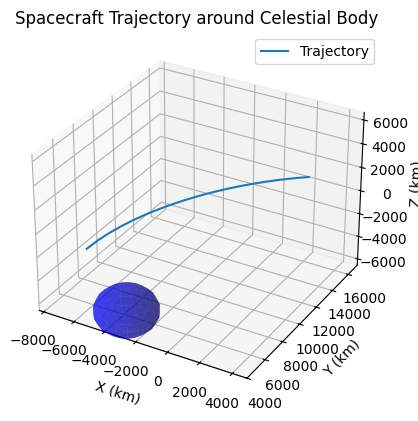

24
0


In [362]:
pos = np.array([-5000, 4000, 100])
r = np.linalg.norm(pos)
v = np.sqrt( moon_mu / r) + 0.2 # km/s, slightly
State0 = [pos[0], pos[1], pos[2], 0, v, 0] 



dt = 1000
op, body_struct = gen_traj(Starting_state=State0, dt=dt)
plot_traj(op.states, body_struct)

print(len(op.states))
print(op.ts[0])


In [363]:
# for 10 points along traj gen images and test CR alg
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(op.states, op.ts, body_struct, cam_offset, camera_spec_ellie, 10)


State at t=0.0s: [-5000.     4000.      100.        0.        1.075     0.   ]
State at t=1000.0s: [-4957.789  5038.336    99.156     0.08      1.002    -0.002]
State at t=2000.0s: [-4846.148  6006.823    96.923     0.14      0.935    -0.003]
State at t=3000.0s: [-4682.419  6911.242    93.648     0.185     0.874    -0.004]
State at t=4000.0s: [-4478.956  7757.374    89.579     0.22      0.819    -0.004]
State at t=5000.0s: [-4244.75   8550.536    84.895     0.247     0.768    -0.005]
State at t=6000.0s: [-3986.487  9295.454    79.73      0.268     0.722    -0.005]
State at t=7000.0s: [-3709.236  9996.276    74.185     0.285     0.68     -0.006]
State at t=8000.0s: [-3416.91  10656.621    68.338     0.299     0.641    -0.006]
State at t=9000.0s: [-3112.578 11279.649    62.252     0.309     0.605    -0.006]


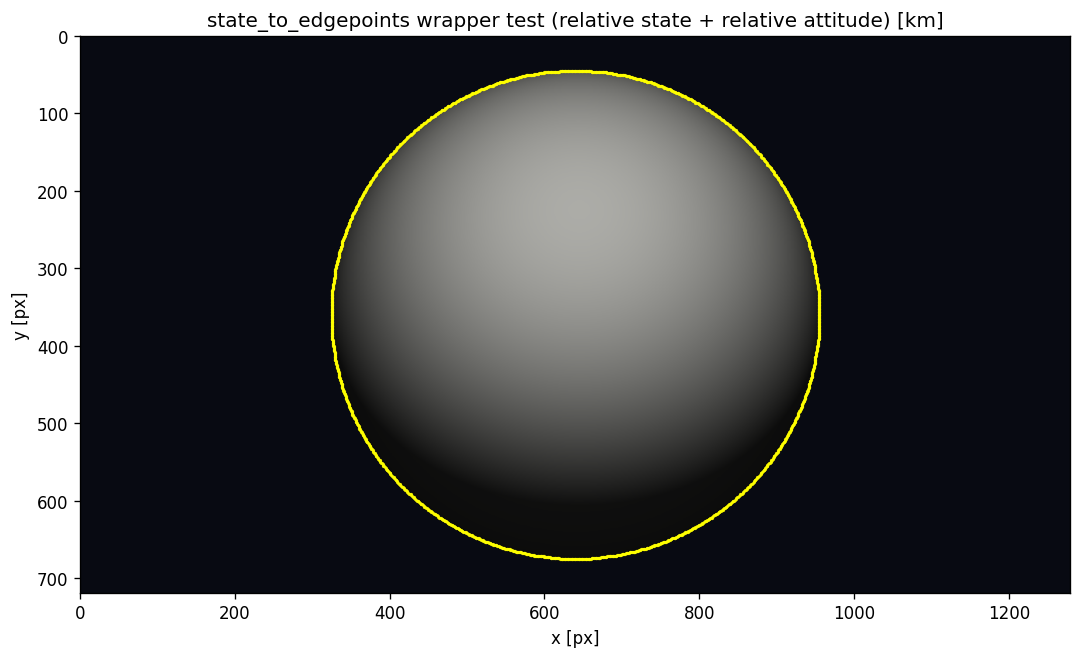

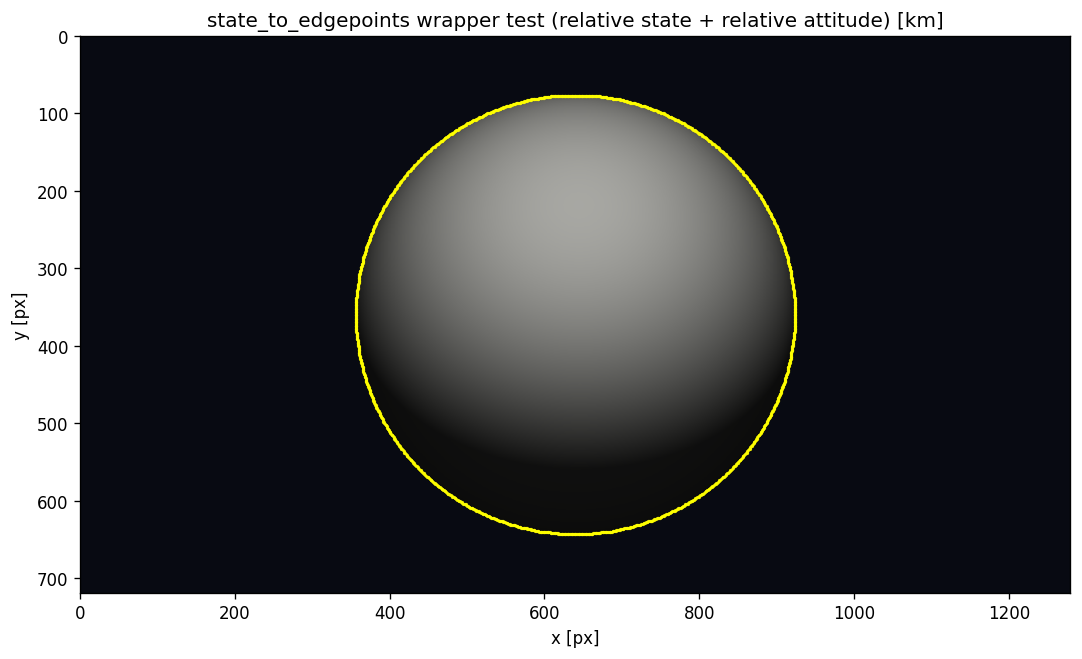

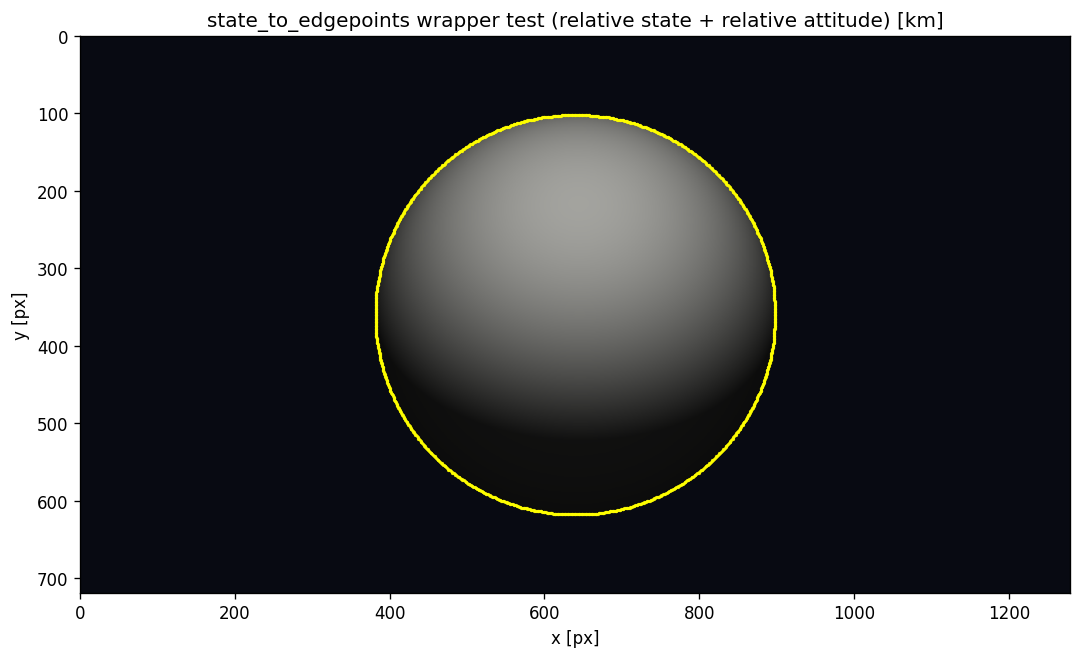

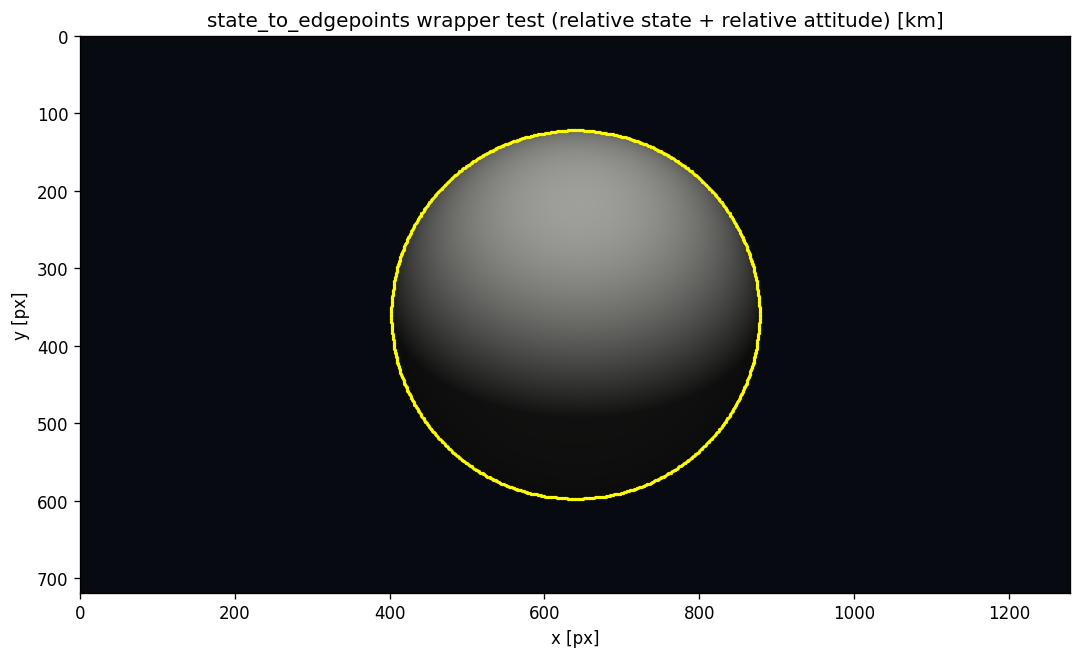

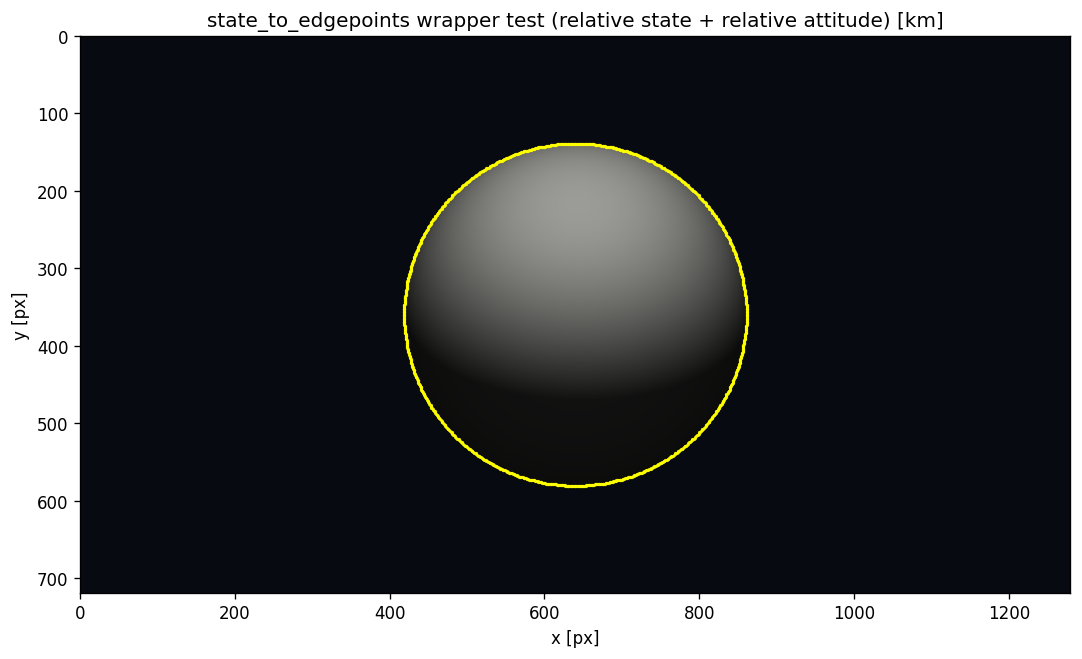

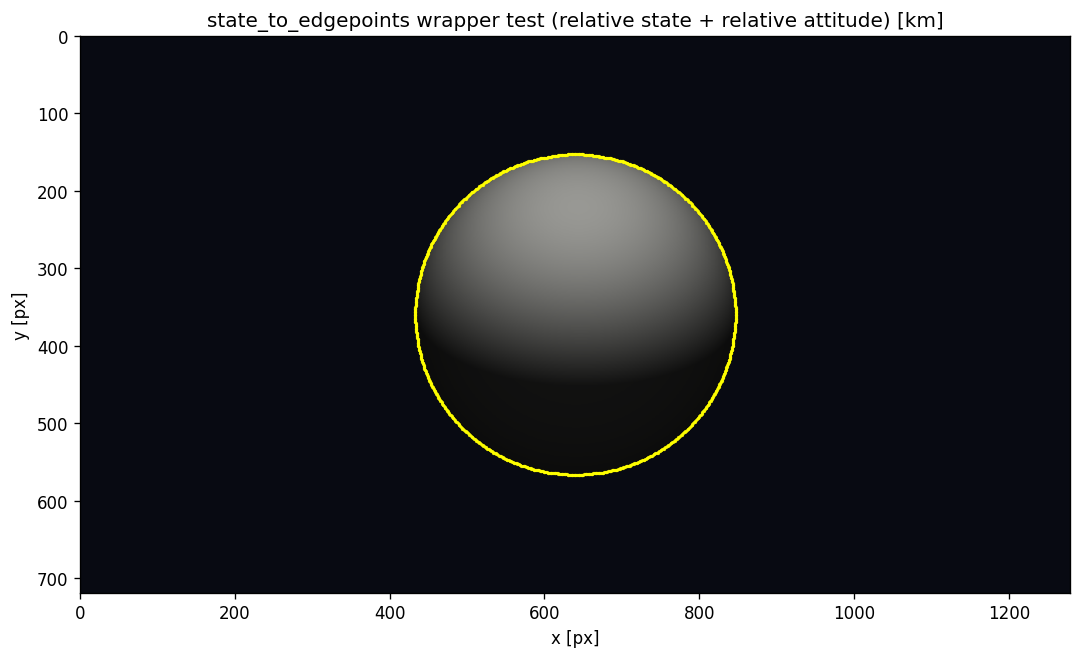

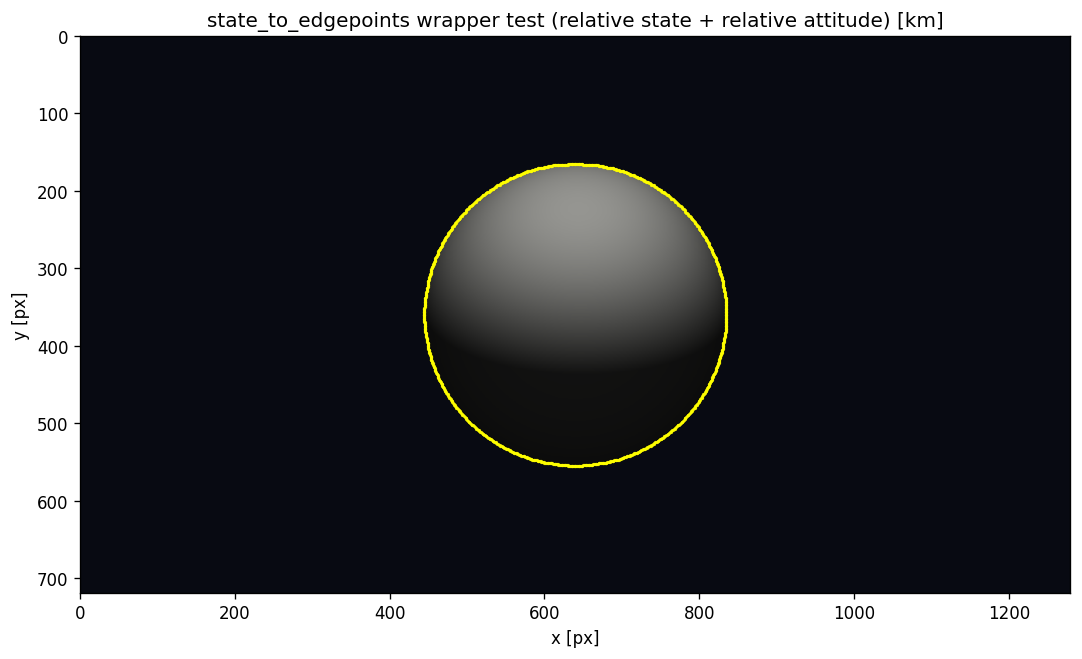

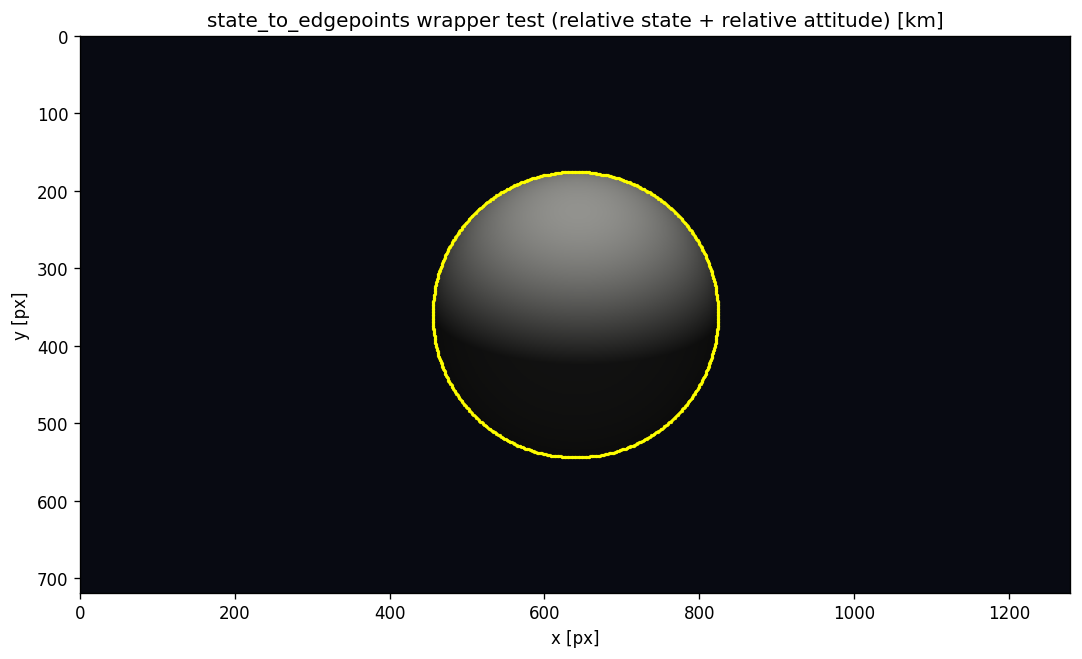

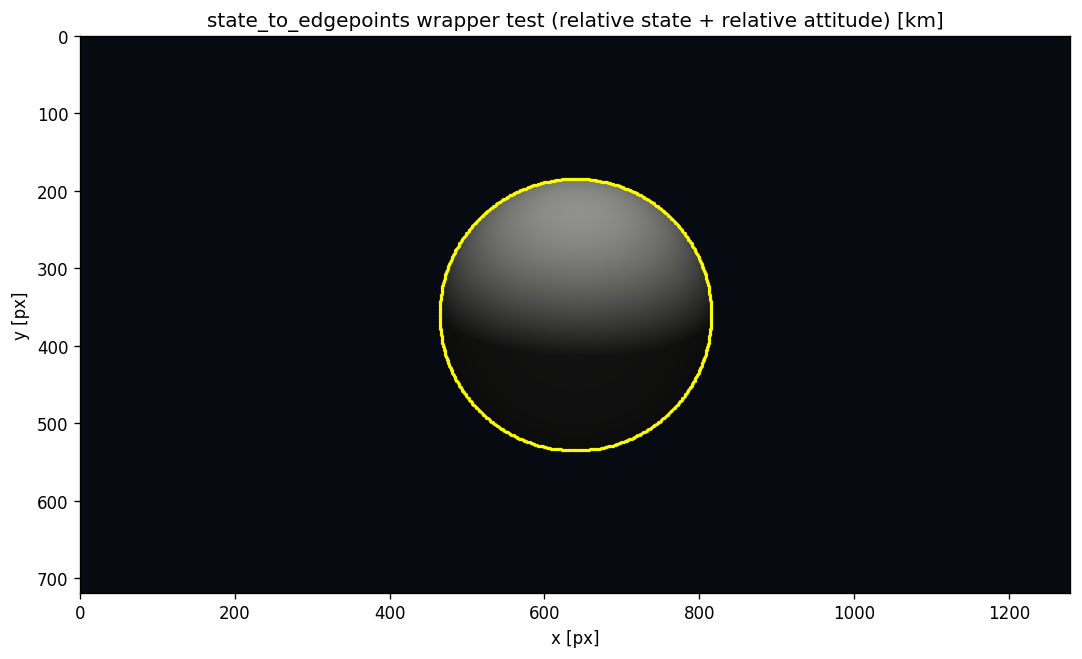

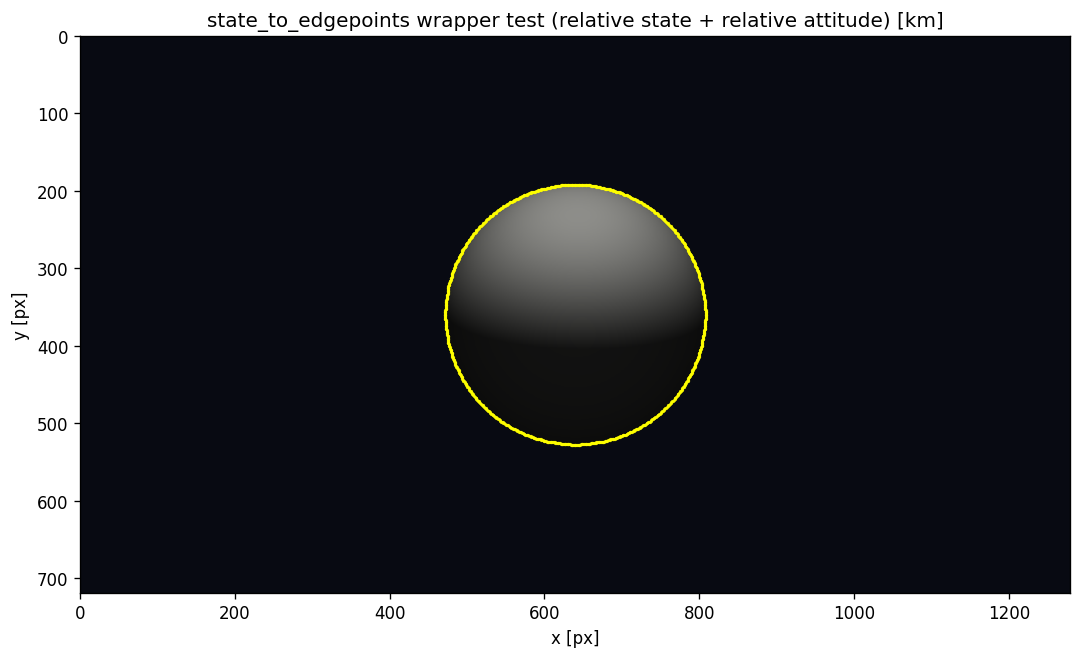

In [364]:

i = 0
for out in outs:
    i += 1
    if i % 1 == 0:
        w, h = camera_spec_ellie["width"], camera_spec_ellie["height"]
        state_to_edgepoints_module.plot_edge_points(
            out,
            w,
            h,
            x_limits=None,
            y_limits=None,
        )

In [365]:

# Test CR Algorithm on Reference Trajectory
# Note: Camera offset is now handled in get_images() via attitude_offset_from_center_pointing
rho_p_est = []  # Will store satellite position vector (planet frame)
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)  # T_c_p: camera to planet frame rotation
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    # Negate rp_est to get satellite position in planet frame (consistent with orientation of truth positions)
    rho_p_est.append(-rp_est)

Running CR alg on image 1/10
Calc Position:
 - (C->P in camera frame): [  -0.     -0.   6413.39] (6413.39 km)
 - (C->P in planet frame): [ 5007.4  -4005.92  -100.15] (6413.39 km)
Actual position:
 - (C->P in camera frame): [  -0.     -0.   6403.91] (6403.91 km)
 - (C->P in planet frame): [ 5000. -4000.  -100.] (6403.91 km)
Est Error - Actual:
 - (Camera frame): [-0.   -0.    9.48] (9.48 km)
 - (Planet frame): [ 7.4  -5.92 -0.15] (9.48 km)
Distance error: 9.48 km (0.148060%)
Angular error: 0.0000 degrees
Running CR alg on image 2/10
Calc Position:
 - (C->P in camera frame): [   0.      0.   7081.89] (7081.89 km)
 - (C->P in planet frame): [ 4966.66 -5047.35   -99.33] (7081.89 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   7069.25] (7069.25 km)
 - (C->P in planet frame): [ 4957.79 -5038.34   -99.16] (7069.25 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   12.64] (12.64 km)
 - (Planet frame): [ 8.87 -9.01 -0.18] (12.64 km)
Distance error: 12.64 km (0.178826%)
Ang

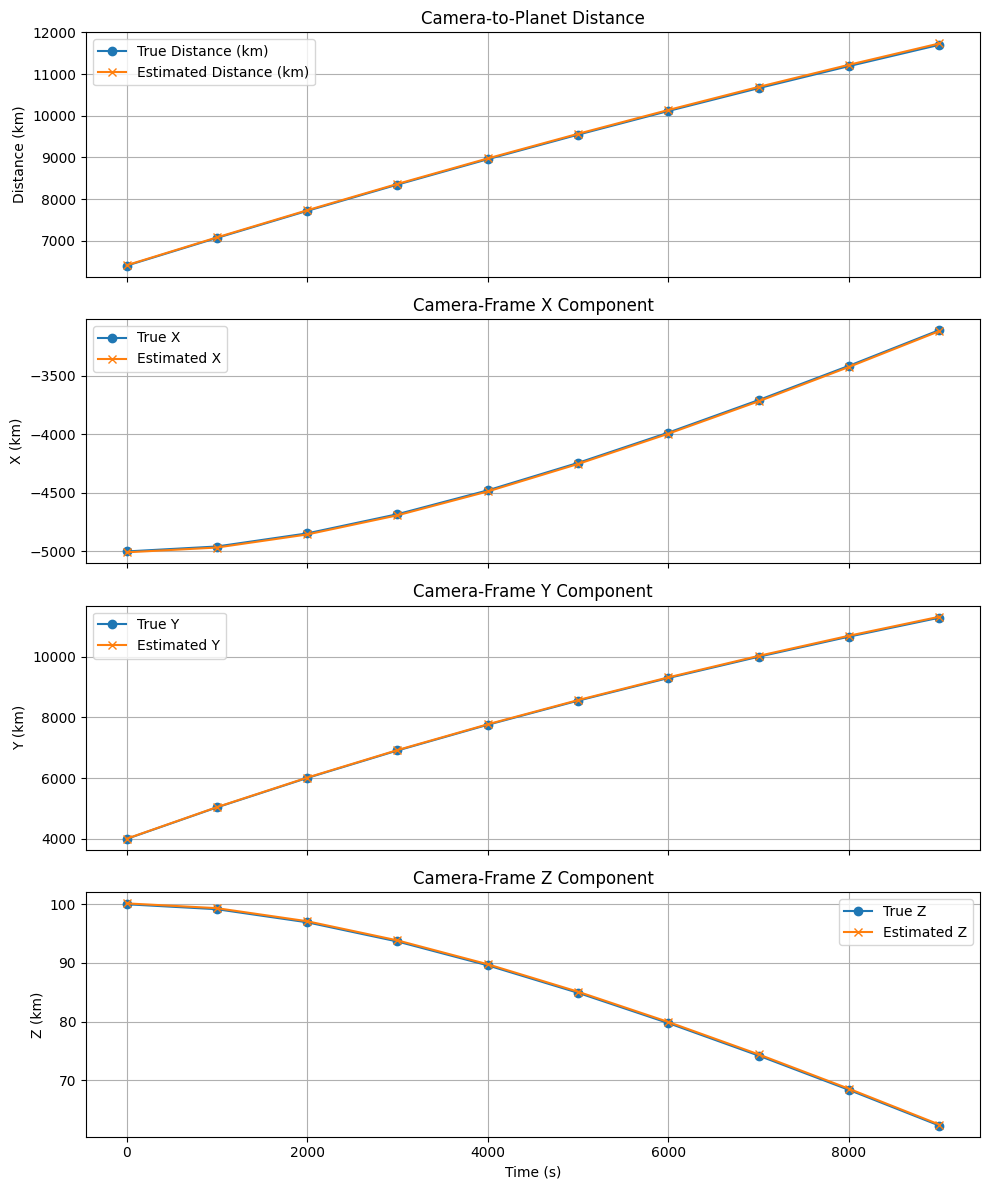

In [366]:
# compare true/estimated camera-frame vectors and distances with optional axis limits
states = np.array(states)
pos = states[:, 0:3]
rho_p_est = np.array(rho_p_est)
times = np.array(times)

#print(np.shape(pos))
#print(estimates[:, 1])
#print("times:", times)

# plt.plot()


plot_est_dist_xyz(
    times,
    pos,
    rho_p_est,
    
)

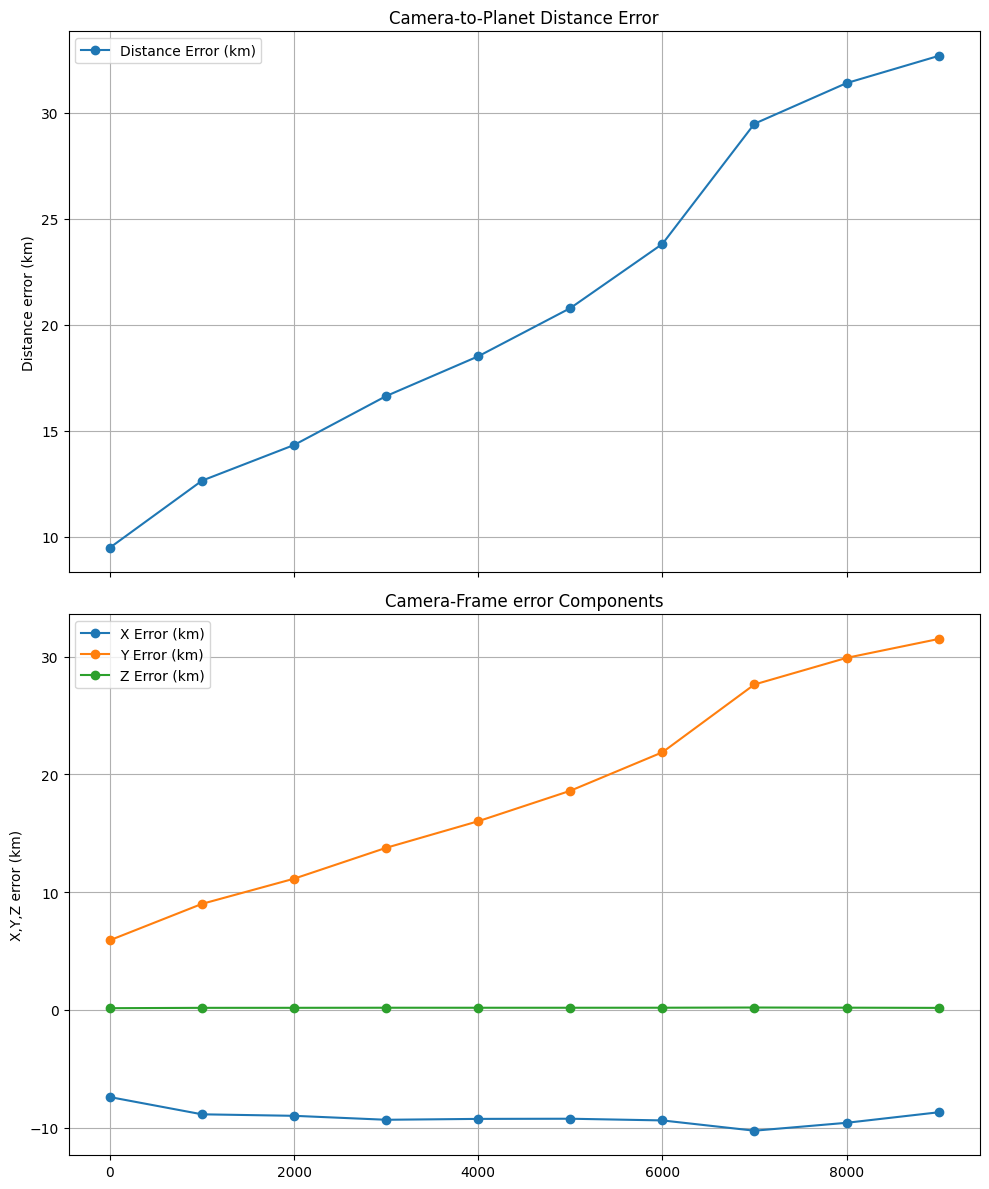

In [367]:
plot_est_dist_xyz_errors(
    times,
    pos,
    rho_p_est,
)

## With EKF Now

In [368]:
# EKF Configuration
Q = np.diag([Q_POS_VARIANCE, Q_POS_VARIANCE, Q_POS_VARIANCE, 
             Q_VEL_VARIANCE, Q_VEL_VARIANCE, Q_VEL_VARIANCE])  # Process noise covariance

Q_perfect = np.zeros((6, 6))  # Perfect process model (no noise)

R = np.diag([R_MEAS_VARIANCE, R_MEAS_VARIANCE, R_MEAS_VARIANCE])  # Measurement noise covariance

dt = TRAJECTORY_DT  # Time step in seconds
N = N_STEPS

state_0 = np.array(State0)
mu0 = state_0
sigma0 = np.diag([1.0, 1.0, 1.0, 0.0001, 0.0001, 0.0001])  # Initial state covariance

central_body_mass = MOON_MU / G  # kg, derived from MOON_MU / G

ekf = SatEKF(Q, R, dt, mu0, sigma0, central_body_mass)

In [369]:
print(Q)

[[10.  0.  0.  0.  0.  0.]
 [ 0. 10.  0.  0.  0.  0.]
 [ 0.  0. 10.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.]]


state_0=array([-5000.   ,  4000.   ,   100.   ,     0.   ,     1.075,     0.   ])


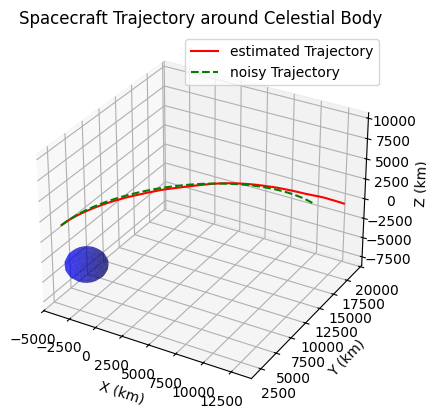

In [370]:
print(f"{state_0=}")
states_perfect = []
states_noisy = []

state_clean = state_0
state_noisy = state_0 + noise(Q)

# get noisy trajectory for EKF testing
states_perfect.append(state_clean)
states_noisy.append(state_noisy)

for i in range(N-1): # N total states, but we already have the initial state in the lists, so we loop N-1 times

    # Perfect trajectory (for comparison)
    state_next_clean = ekf.f_func(state_clean) 

    # Noisy/realistic trajectory
    process_noise = noise(Q)
    state_next_noisy = ekf.f_func(state_noisy) + process_noise



    state_noisy = state_next_noisy
    state_clean = state_next_clean 

    states_perfect.append(state_clean)
    states_noisy.append(state_noisy)


states_noisy = np.array(states_noisy)
states_perfect = np.array(states_perfect)

ts = np.arange(0, N) * dt  # Now includes all N+1 states

plot_trajs(states_noisy, states_perfect, body_struct)

In [371]:
# get CR estimates for EKF measurement updates
print(ts[i])
print(states_noisy[i])
cam_offset = np.array([0, 0, 0]) # no offset for now
images, edges, outs, states, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)


48000
[13915.151 16386.367  1951.994     0.378    -0.108     0.061]
State at t=0.0s: [-5000.761  3998.66     99.404     0.005     1.067    -0.015]
State at t=1000.0s: [-4944.391  5030.499    82.02      0.117     0.989    -0.026]
State at t=2000.0s: [-4798.667  5980.499    55.175     0.188     0.912    -0.02 ]
State at t=3000.0s: [-4580.911  6857.855    39.926     0.243     0.847    -0.007]
State at t=4000.0s: [-4313.508  7672.799    32.637     0.291     0.796     0.01 ]
State at t=5000.0s: [-4000.95   8440.385    43.173     0.339     0.724     0.015]
State at t=6000.0s: [-3650.236  9139.041    59.232     0.349     0.691    -0.   ]
State at t=7000.0s: [-3289.277  9804.009    59.902     0.348     0.642     0.01 ]
State at t=8000.0s: [-2929.542 10424.057    69.627     0.373     0.593    -0.003]
State at t=9000.0s: [-2551.568 11001.       63.395     0.391     0.547     0.007]
State at t=10000.0s: [-2159.13  11528.325    73.099     0.387     0.508     0.021]
State at t=11000.0s: [-1772.742 

KeyboardInterrupt: 

In [ ]:
# Generate Measurements from Noisy Trajectory
rp_est_CR = []  # CR estimates in planet frame
rc_est_CR = []  # CR measurements in camera frame
planet_to_camera_rotations = []  # T_c_p matrices for each timestep
for i in range(len(outs)):
    print(f"Running CR alg on image {i+1}/{len(outs)}")
    out = outs[i]
    state = states[i]
    edge = edges[i]
    
    # Compute camera-to-planet rotation matrix T_c_p from render output
    T_c_p = get_T_c_p(out)
    planet_to_camera_rotations.append(T_c_p)
    
    # Prepare edge points as homogeneous coordinates [x, y, 1]
    edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))

    # Run Christian-Robinson: returns camera->planet vector in camera frame (rc_est) 
    # and planet location in planet frame (rp_est)
    rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=True, cr_alg=cr_alg)
    rp_est_CR.append(rp_est)
    rc_est_CR.append(rc_est)

Running CR alg on image 1/50
Calc Position:
 - (C->P in camera frame): [   0.     -0.   6409.42] (6409.42 km)
 - (C->P in planet frame): [ 5002.49 -4005.85   -94.43] (6409.42 km)
Actual position:
 - (C->P in camera frame): [   0.      0.   6399.39] (6399.39 km)
 - (C->P in planet frame): [ 4994.66 -3999.58   -94.28] (6399.39 km)
Est Error - Actual:
 - (Camera frame): [ 0.   -0.   10.03] (10.03 km)
 - (Planet frame): [ 7.83 -6.27 -0.15] (10.03 km)
Distance error: 10.03 km (0.156725%)
Angular error: 0.0000 degrees
Running CR alg on image 2/50
Calc Position:
 - (C->P in camera frame): [   0.      0.   7081.57] (7081.57 km)
 - (C->P in planet frame): [ 4955.01 -5058.47   -92.07] (7081.57 km)
Actual position:
 - (C->P in camera frame): [   0.     -0.   7069.07] (7069.07 km)
 - (C->P in planet frame): [ 4946.25 -5049.54   -91.91] (7069.07 km)
Est Error - Actual:
 - (Camera frame): [ 0.    0.   12.51] (12.51 km)
 - (Planet frame): [ 8.75 -8.93 -0.16] (12.51 km)
Distance error: 12.51 km (0.176

In [ ]:
len(outs), len(rp_est_CR), len(rc_est_CR), len(planet_to_camera_rotations)

(50, 50, 50, 50)

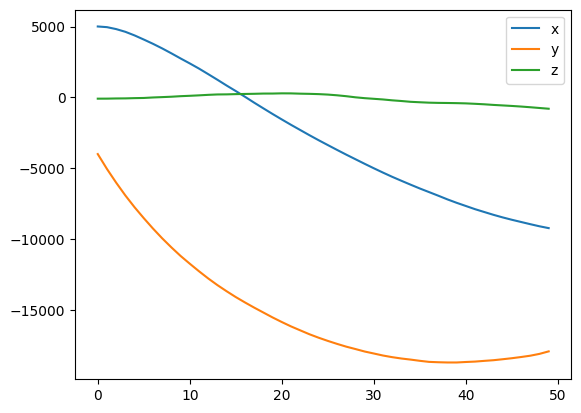

In [ ]:
# Plot CR estimates in planet frame
plt.plot(rp_est_CR)
plt.legend(["x", "y", "z"])

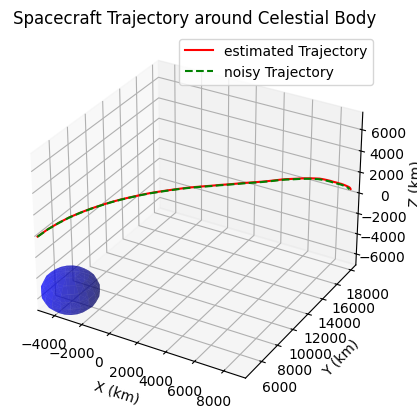

In [ ]:
rp_est_CR = np.array(rp_est_CR)

plot_trajs(-rp_est_CR, states_noisy, body_struct)

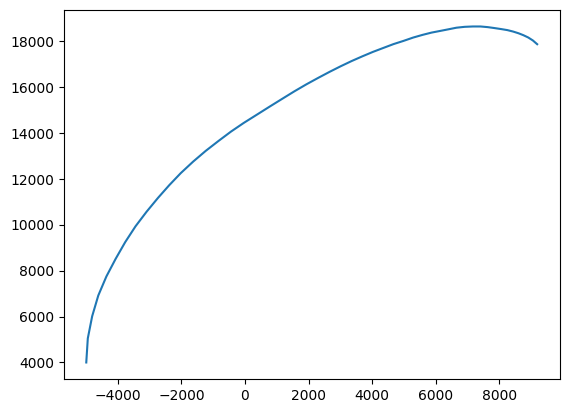

In [ ]:
plt.plot(states_noisy[:, 0], states_noisy[:, 1], label="True x")

In [ ]:
# EKF Estimation Loop
mus = []  # EKF state estimates over time
sigmas = []  # EKF covariances over time
mus.append(ekf.mu)
sigmas.append(ekf.sigma)

for i in range(N): # N total states, but we already have the initial state in the lists, so we loop N-1 times
    print(f"EKF step {i+1}/{N}")
    ekf.predict()
    measurement = -rc_est_CR[i]  # Negate for measurement model
    print("Measurement:", measurement)
    print("Predicted state:", ekf.mu)
    ekf.update(measurement, planet_to_camera_rotations[i])
    mus.append(ekf.mu)
    sigmas.append(ekf.sigma)

print("Final EKF state estimate:", ekf.mu)

EKF step 1/50
Measurement: [   -0.        0.    -6409.422]
Predicted state: [-4953.329  5037.646    99.067     0.093     1.       -0.002]
Measurement function output: [   -5.568  -836.116 -7015.984]
EKF step 2/50
Measurement: [   -0.       -0.    -7081.575]
Predicted state: [-4868.591  4969.654    91.772     0.151     0.438    -0.006]
Measurement function output: [   -1.307     0.437 -6957.662]
EKF step 3/50
Measurement: [   -0.      -0.   -7714.74]
Predicted state: [-4791.358  5483.856    85.882     0.177     0.412    -0.007]
Measurement function output: [   -6.799   317.716 -7275.725]
EKF step 4/50
Measurement: [    0.        0.    -8331.948]
Predicted state: [-4623.098  6533.638    70.883     0.216     0.599    -0.011]
Measurement function output: [    3.337   217.831 -8001.189]
EKF step 5/50
Measurement: [   -0.       0.   -8908.17]
Predicted state: [-4391.336  7595.696    64.213     0.254     0.726    -0.01 ]
Measurement function output: [   -7.595    99.339 -8773.405]
EKF step 6/

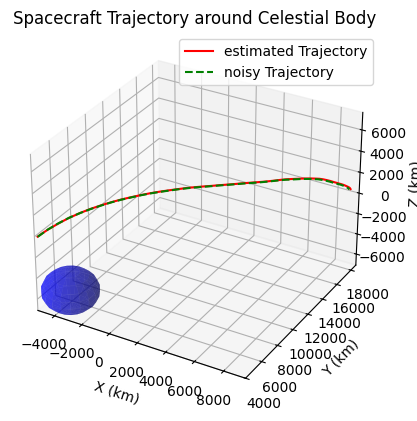

In [ ]:
mus = np.array(mus)
sigmas = np.array(sigmas)
plot_trajs(mus, states_noisy, body_struct)


Final EKF state estimate: [ 9237.184 17948.634   803.462     0.134    -0.158     0.051]


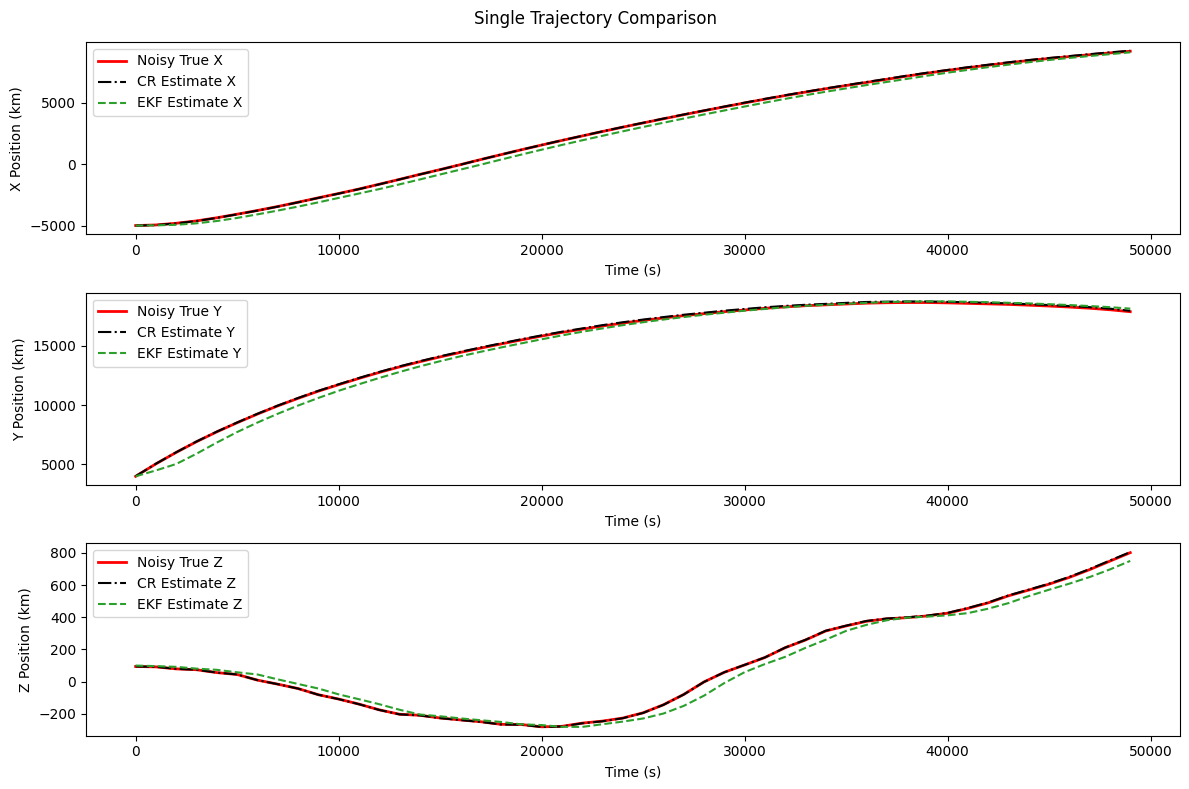

In [ ]:
# plot EKF estimates vs true trajectory and CR estimates vs time
mus = np.array(mus)
states_noisy = np.array(states_noisy)
    

plt.figure(figsize=(12, 8))
plt.suptitle("Single Trajectory Comparison")
plt.subplot(3, 1, 1)
print("Final EKF state estimate:", ekf.mu)
# Align array lengths with ts (mus and states_noisy are length 51, ts is 50)
mus = mus[:len(ts)]
states_noisy = states_noisy[:len(ts)]
plt.plot(ts, states_noisy[:, 0], label='Noisy True X', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 0], label='CR Estimate X', color='k', linestyle='-.')
plt.plot(ts, mus[:, 0], label='EKF Estimate X', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 0], label='Perfect True X', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('X Position (km)')
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(ts, states_noisy[:, 1], label='Noisy True Y', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 1], label='CR Estimate Y', color='k', linestyle='-.')
plt.plot(ts, mus[:, 1], label='EKF Estimate Y', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 1], label='Perfect True Y', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Y Position (km)')
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(ts, states_noisy[:, 2], label='Noisy True Z', color='red', linewidth=2)
plt.plot(ts, -rp_est_CR[:, 2], label='CR Estimate Z', color='k', linestyle='-.')
plt.plot(ts, mus[:, 2], label='EKF Estimate Z', color='tab:green', linestyle='--')
# plt.plot(ts, states_perfect[:, 2], label='Perfect True Z', color='blue', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Z Position (km)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
EKF_err = mus - states_noisy
CR_err = -rp_est_CR - states_noisy[:, :3]

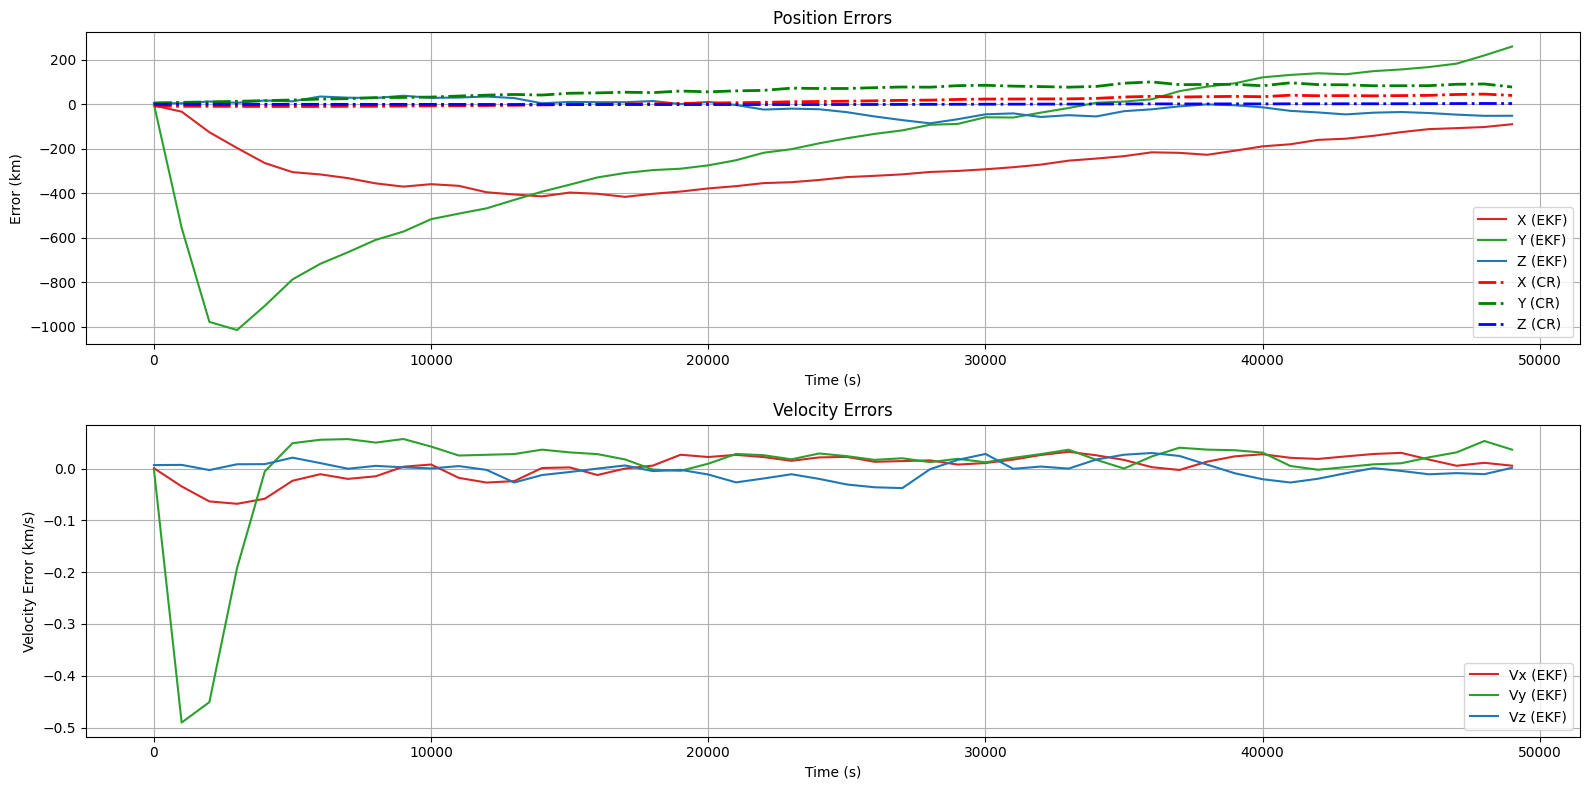

In [ ]:
# Uncomment to plot velocity errors
plt.figure(figsize=(16, 8))
plt.subplot(2, 1, 2)
plt.title("Velocity Errors")
plt.plot(ts, EKF_err[:,3], label='Vx (EKF)', color="tab:red")
plt.plot(ts, EKF_err[:,4], label='Vy (EKF)', color="tab:green")
plt.plot(ts, EKF_err[:,5], label='Vz (EKF)', color="tab:blue")
plt.xlabel('Time (s)')
plt.ylabel('Velocity Error (km/s)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 1)
plt.title("Position Errors")
plt.plot(ts, EKF_err[:,0], label='X (EKF)', color="tab:red")
plt.plot(ts, EKF_err[:,1], label='Y (EKF)', color="tab:green")
plt.plot(ts, EKF_err[:,2], label='Z (EKF)', color="tab:blue")
plt.plot(ts, CR_err[:,0], "-.", label='X (CR)', color="red", linewidth=2)
plt.plot(ts, CR_err[:,1], "-.", label='Y (CR)', color="green", linewidth=2)
plt.plot(ts, CR_err[:,2], "-.", label='Z (CR)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Error (km)')
# plt.ylim(-200, 200)  # Zoom in
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
rp_est_CR_norm = np.apply_along_axis(np.linalg.norm, 1, rp_est_CR[:,:3])
rp_est_EKF_norm = np.apply_along_axis(np.linalg.norm, 1, mus[:,:3])

state_norm_perfect = np.apply_along_axis(np.linalg.norm, 1, states_perfect[:,:3])
state_norm_noisy = np.apply_along_axis(np.linalg.norm, 1, states_noisy[:,:3])

EKF State 0 Error: [ 0.28  7.73 -0.01  0.   -0.01  0.  ]


<Figure size 1000x600 with 0 Axes>

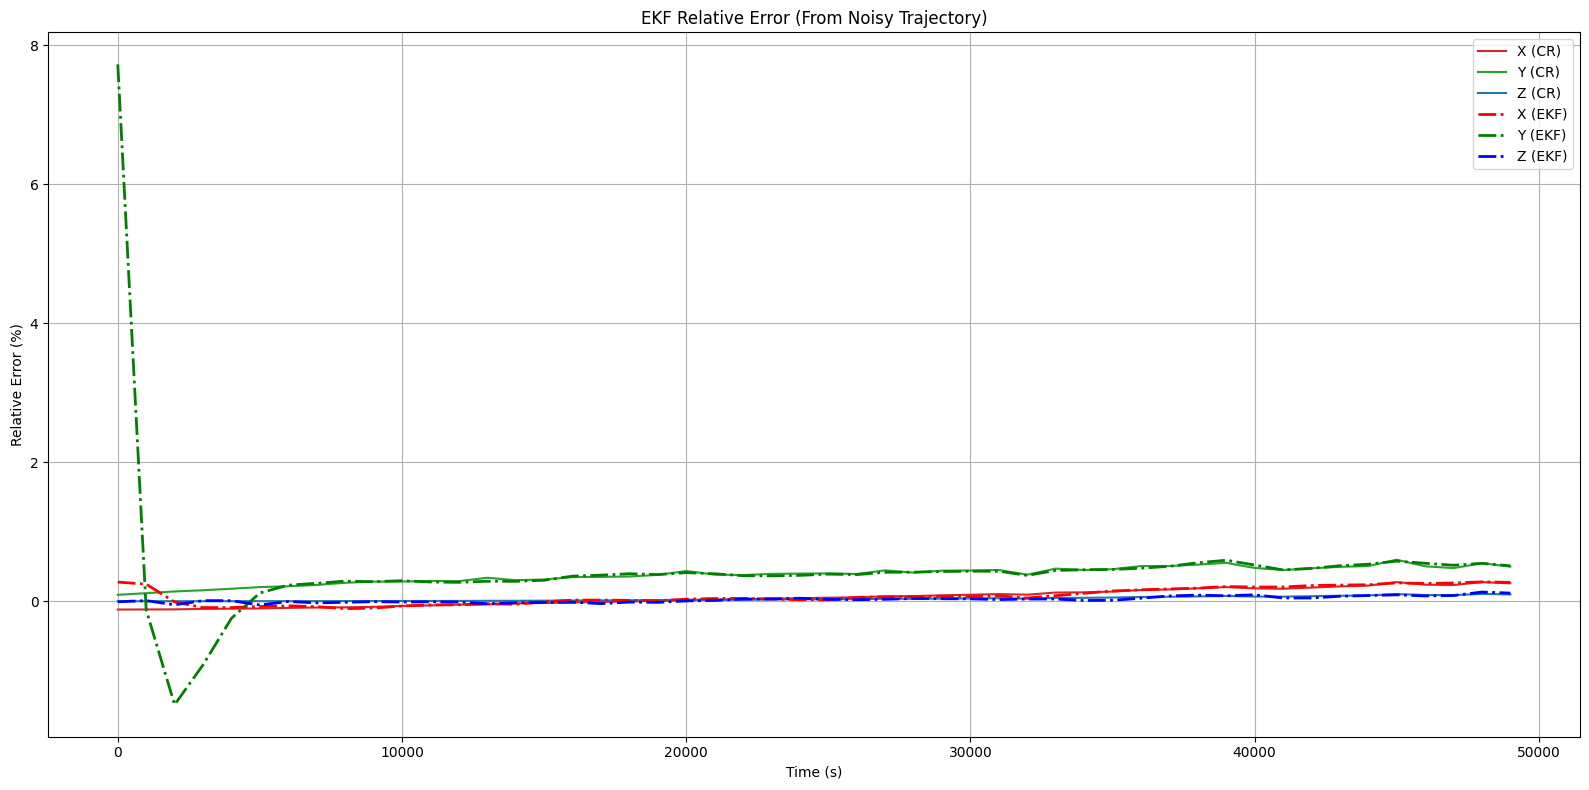

CR State 0 Error: [-0.118  0.094  0.002]
CR State 0 Error: 0.1507357941502573
EKF State 0 Error: [ 0.277  7.727 -0.006]
EKF State 0 Error: 7.732101044954823
CR State -1 Error: [0.26 0.5  0.1 ]
CR State -1 Error: 0.5720110835536031
EKF State -1 Error: [0.273 0.511 0.119]
EKF State -1 Error: 0.5916226663795692


In [ ]:
CR_err_rel = 100*CR_err / state_norm_noisy[:,None]
EKF_err_rel = 100*EKF_err / state_norm_noisy[:,None]

np.set_printoptions(precision=3, suppress=True)

# Overall RMS (across all trajectories and time)
CR_overall_rms = np.sqrt(np.mean(CR_err_rel**2))
EKF_overall_rms = np.sqrt(np.mean(EKF_err_rel[:,:3]**2))



print(f"EKF State 0 Error: {np.round(EKF_err_rel[0], 2)}")

plt.figure(figsize=(10, 6))

plt.figure(figsize=(16, 8))
plt.title("EKF Relative Error (From Noisy Trajectory)")
plt.plot(ts, CR_err_rel[:,0], label='X (CR)', color="tab:red")
plt.plot(ts, CR_err_rel[:,1], label='Y (CR)', color="tab:green")
plt.plot(ts, CR_err_rel[:,2], label='Z (CR)', color="tab:blue")
plt.plot(ts, EKF_err_rel[:,0], "-.", label='X (EKF)', color="red", linewidth=2)
plt.plot(ts, EKF_err_rel[:,1], "-.", label='Y (EKF)', color="green", linewidth=2)
plt.plot(ts, EKF_err_rel[:,2], "-.", label='Z (EKF)', color="blue", linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Relative Error (%)')
plt.legend()
# plt.ylim(-5, 5)
plt.grid(True)

plt.tight_layout()
plt.show()

CR_0 = CR_err_rel[0]
EKF_0 = EKF_err_rel[0, :3]

print(f"CR State 0 Error: {CR_0}")
print(f"CR State 0 Error: {norm(CR_0)}")
print(f"EKF State 0 Error: {EKF_0}")
print(f"EKF State 0 Error: {norm(EKF_0)}")

CR_0 = CR_err_rel[-1]
EKF_0 = EKF_err_rel[-1, :3]

print(f"CR State -1 Error: {CR_0}")
print(f"CR State -1 Error: {norm(CR_0)}")
print(f"EKF State -1 Error: {EKF_0}")
print(f"EKF State -1 Error: {norm(EKF_0)}")

## Monte carlo-ish

In [ ]:
# Monte Carlo Simulation: Generate multiple trajectories, run CR and EKF, collect statistics
N_TRAJECTORIES = 5  # Reduced to 5 for faster testing

# Storage for errors
CR_errors_all = []  # List of CR position errors over time for each trajectory
EKF_errors_all = []  # List of EKF position errors over time for each trajectory

mus_all = []  # Store EKF state estimates for all trajectories
sigmas_all = []  # Store EKF cov estimates for all trajectories

rp_est_CR_all = []  # Store CR estimates for all trajectories
rc_est_CR_all = []  # Store CR estimates for all trajectories

# images_all = []  # Store images for all trajectories (optional, can consume a lot of memory)
# edges_all = []   # Store edges for all trajectories (optional)
# outs_all = []   # Store render outputs for all trajectories (optional) 
# states_meas_all = []  # Store measured states for all trajectories (optional)
# times_all = []  # Store times for all trajectories (optional)

ts = np.arange(0, N) * dt  # Now includes all N+1 states

for traj_idx in range(N_TRAJECTORIES):
    print(f"Trajectory {traj_idx + 1}/{N_TRAJECTORIES}")
    
    # Generate noisy trajectory (similar to earlier cell)
    states_perfect = []
    states_noisy = []
    state_clean = np.array(State0)
    state_noisy = state_clean + noise(Q)

    # get noisy trajectory for EKF testing
    states_perfect.append(state_clean)
    states_noisy.append(state_noisy)
    
    for i in range(N-1): # N total states, but we already have the initial state in the lists, so we loop N-1 times
        
        state_next_clean = ekf.f_func(state_clean)
        process_noise = noise(Q)
        state_next_noisy = ekf.f_func(state_noisy) + process_noise
        
        state_noisy = state_next_noisy
        state_clean = state_next_clean

        states_perfect.append(state_clean)
        states_noisy.append(state_noisy)
    
    states_noisy = np.array(states_noisy)
    states_perfect = np.array(states_perfect)
    
    # Generate images and CR estimates
    cam_offset = np.array([0, 0, 0])
    images, edges, outs, states_meas, times = get_images(states_noisy, ts, body_struct, cam_offset, camera_spec_ellie, N)
    
    rp_est_CR = []
    rc_est_CR = []
    planet_to_camera_rotations = []
    for i in range(len(outs)):
        out = outs[i]
        state = states_meas[i]
        edge = edges[i]
        
        T_c_p = get_T_c_p(out)
        planet_to_camera_rotations.append(T_c_p)
        
        edge_homogeneous = np.hstack((edge, np.ones((edge.shape[0], 1))))
        rc_est, rp_est = run_step(edge_homogeneous, state[0:3], T_c_p, print_stats=False, cr_alg=cr_alg)
        rp_est_CR.append(rp_est)
        rc_est_CR.append(rc_est)
    
    rp_est_CR = np.array(rp_est_CR)
    rc_est_CR = np.array(rc_est_CR)
    
    # Run EKF
    ekf_mc = SatEKF(Q, R, dt, np.array(State0), sigma0, central_body_mass)  # Fresh EKF for each trajectory
    mus = []
    sigmas = []
    for i in range(N):
        ekf_mc.predict()
        measurement = -rc_est_CR[i]
        ekf_mc.update(measurement, planet_to_camera_rotations[i])
        mus.append(ekf_mc.mu)
        sigmas.append(ekf_mc.mu)
    mus = np.array(mus)
    sigmas = np.array(sigmas)
    
    # Compute errors
    CR_err = (-rp_est_CR) - states_noisy[:len(rp_est_CR), :3]  # CR position error
    EKF_err = mus - states_noisy[:len(mus), :]  # EKF full state error
    
    rp_est_CR_all.append(rp_est_CR)
    rc_est_CR_all.append(rc_est_CR)
    CR_errors_all.append(CR_err)
    EKF_errors_all.append(EKF_err)  # Only position for comparison
    mus_all.append(mus)
    sigmas_all.append(sigmas)

print("Done computing trajectories and errors")

Trajectory 1/5
State at t=0.0s: [-4999.75   3996.687   103.613    -0.011     1.099     0.009]
State at t=1000.0s: [-4964.645  5059.512   108.024     0.097     1.023     0.015]
State at t=2000.0s: [-4834.16   6047.981   126.073     0.173     0.971     0.009]
State at t=3000.0s: [-4631.894  6988.546   137.708     0.211     0.908     0.002]
State at t=4000.0s: [-4398.624  7867.638   139.081     0.25      0.878    -0.014]
State at t=5000.0s: [-4133.66   8720.606   120.026     0.297     0.807    -0.026]
State at t=6000.0s: [-3827.1    9502.387    93.296     0.312     0.776    -0.029]
State at t=7000.0s: [-3508.828 10257.802    62.523     0.337     0.728    -0.037]
State at t=8000.0s: [-3163.228 10957.562    25.493     0.341     0.687    -0.058]
State at t=9000.0s: [-2815.478 11624.202   -31.878     0.361     0.649    -0.055]
State at t=10000.0s: [-2450.96  12257.8     -88.199     0.364     0.609    -0.05 ]
State at t=11000.0s: [-2083.583 12849.373  -135.456     0.391     0.572    -0.056]
St

In [ ]:
# Convert to arrays for statistics
CR_errors_all = np.array(CR_errors_all)  # Shape: (N_TRAJECTORIES, N, 3)
EKF_errors_all = np.array(EKF_errors_all)  # Shape: (N_TRAJECTORIES, N, 6)

# Compute statistics over trajectories
CR_mean_error = np.mean(CR_errors_all, axis=0)  # Mean error over time
CR_std_error = np.std(CR_errors_all, axis=0)     # Std dev over time
EKF_mean_error = np.mean(EKF_errors_all[:,:,:3], axis=0) # only for position
EKF_std_error = np.std(EKF_errors_all[:,:,:3], axis=0) # only for position

print("Statistics computed. Plotting...")

Statistics computed. Plotting...


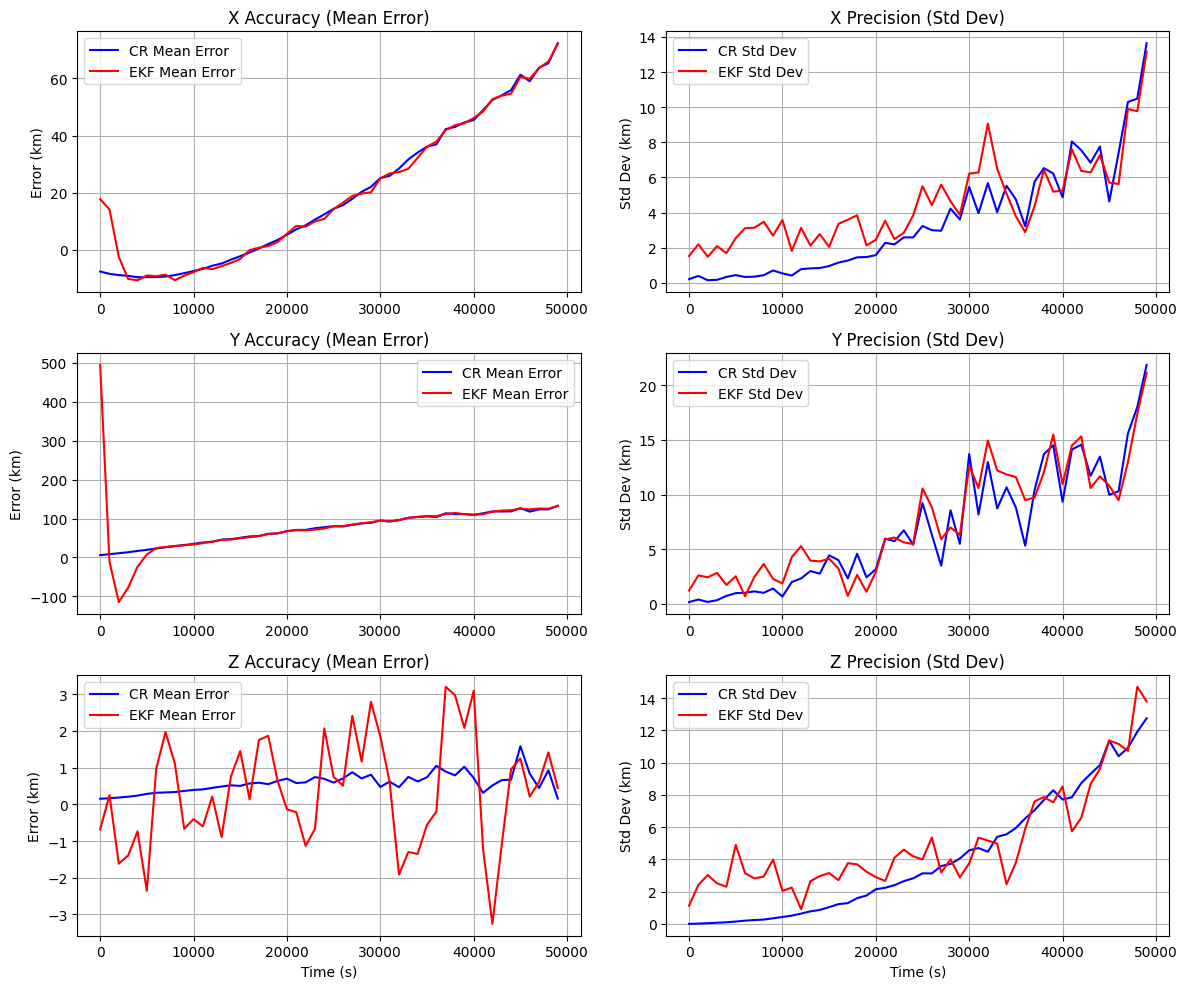

Final Step (t=49000s) Statistics:
CR Mean Error: [ 72.269 133.134   0.159] km
CR Std Dev: [13.645 21.861 12.758] km
EKF Mean Error: [ 71.947 132.527   0.443] km
EKF Std Dev: [13.16  21.145 13.801] km


In [ ]:
# Plot accuracy (mean error) and precision (std dev) for CR and EKF
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
components = ['X', 'Y', 'Z']

for i in range(3):
    # Accuracy: Mean error
    axes[i, 0].plot(ts[:len(CR_mean_error)], CR_mean_error[:, i], label='CR Mean Error', color='blue')
    axes[i, 0].plot(ts[:len(EKF_mean_error)], EKF_mean_error[:, i], label='EKF Mean Error', color='red')
    axes[i, 0].set_title(f'{components[i]} Accuracy (Mean Error)')
    axes[i, 0].set_ylabel('Error (km)')
    axes[i, 0].legend()
    axes[i, 0].grid(True)
    
    # Precision: Std dev
    axes[i, 1].plot(ts[:len(CR_std_error)], CR_std_error[:, i], label='CR Std Dev', color='blue')
    axes[i, 1].plot(ts[:len(EKF_std_error)], EKF_std_error[:, i], label='EKF Std Dev', color='red')
    axes[i, 1].set_title(f'{components[i]} Precision (Std Dev)')
    axes[i, 1].set_ylabel('Std Dev (km)')
    axes[i, 1].legend()
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

# Print final statistics
print("Final Step (t=49000s) Statistics:")
print(f"CR Mean Error: {CR_mean_error[-1]} km")
print(f"CR Std Dev: {CR_std_error[-1]} km")
print(f"EKF Mean Error: {EKF_mean_error[-1]} km")
print(f"EKF Std Dev: {EKF_std_error[-1]} km")

Additional Monte Carlo Statistics:
CR RMS Error (per component, final step): [ 73.546 134.917  12.759] km
EKF RMS Error (per component, final step): [ 73.141 134.203  13.809   0.02    0.018   0.012] km
CR Overall RMS: 51.6384175694379 km
EKF Overall RMS: 47.11764982405966 km
CR Max Error: [ 94.74  168.768  21.464] km
CR Min Error: [0.077 5.755 0.041] km
EKF Max Error: [ 93.14  496.558  27.113   0.083   0.59    0.042] km
EKF Min Error: [0.044 3.853 0.022 0.    0.    0.   ] km


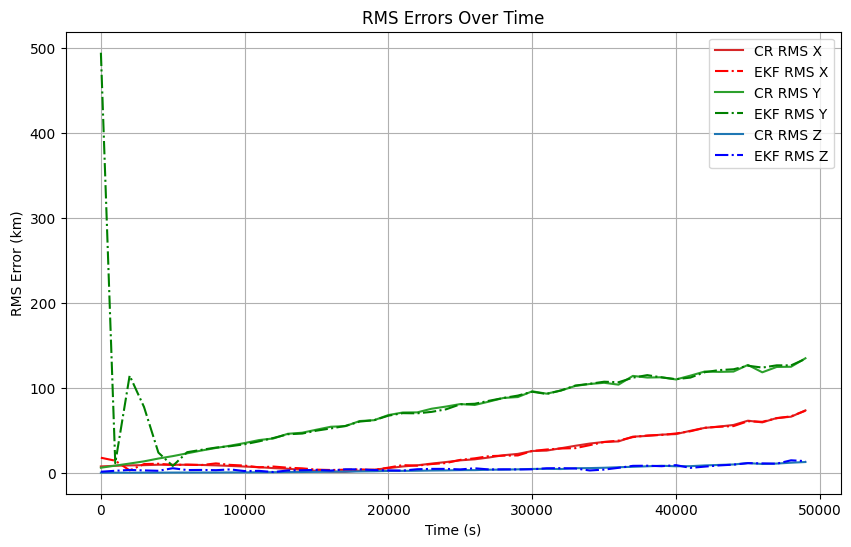

In [ ]:
# Compute additional statistics from Monte Carlo data

# RMS errors over trajectories and time
CR_rms_error = np.sqrt(np.mean(CR_errors_all**2, axis=0))  # Shape: (N, 3)
EKF_rms_error = np.sqrt(np.mean(EKF_errors_all**2, axis=0))  # Shape: (N, 3)

# Overall RMS (across all trajectories and time)
CR_overall_rms = np.sqrt(np.mean(CR_errors_all**2))
EKF_overall_rms = np.sqrt(np.mean(EKF_errors_all**2))

# Max and min errors
CR_max_error = np.max(np.abs(CR_errors_all), axis=(0,1))  # Max per component
CR_min_error = np.min(np.abs(CR_errors_all), axis=(0,1))
EKF_max_error = np.max(np.abs(EKF_errors_all), axis=(0,1))
EKF_min_error = np.min(np.abs(EKF_errors_all), axis=(0,1))

# Print additional statistics
print("Additional Monte Carlo Statistics:")
print(f"CR RMS Error (per component, final step): {CR_rms_error[-1]} km")
print(f"EKF RMS Error (per component, final step): {EKF_rms_error[-1]} km")
print(f"CR Overall RMS: {CR_overall_rms} km")
print(f"EKF Overall RMS: {EKF_overall_rms} km")
print(f"CR Max Error: {CR_max_error} km")
print(f"CR Min Error: {CR_min_error} km")
print(f"EKF Max Error: {EKF_max_error} km")
print(f"EKF Min Error: {EKF_min_error} km")

# Plot RMS errors over time
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts[:len(CR_rms_error)], CR_rms_error[:, 0], label='CR RMS X', color='tab:red')
ax.plot(ts[:len(EKF_rms_error)], EKF_rms_error[:, 0], label='EKF RMS X', color='red', linestyle='-.')
ax.plot(ts[:len(CR_rms_error)], CR_rms_error[:, 1], label='CR RMS Y', color='tab:green')
ax.plot(ts[:len(EKF_rms_error)], EKF_rms_error[:, 1], label='EKF RMS Y', color='green', linestyle='-.')
ax.plot(ts[:len(CR_rms_error)], CR_rms_error[:, 2], label='CR RMS Z', color='tab:blue')
ax.plot(ts[:len(EKF_rms_error)], EKF_rms_error[:, 2], label='EKF RMS Z', color='blue', linestyle='-.')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RMS Error (km)')
ax.set_title('RMS Errors Over Time')
ax.legend()
ax.grid(True)
plt.show()